========== FIRST 5 ROWS ==========
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            

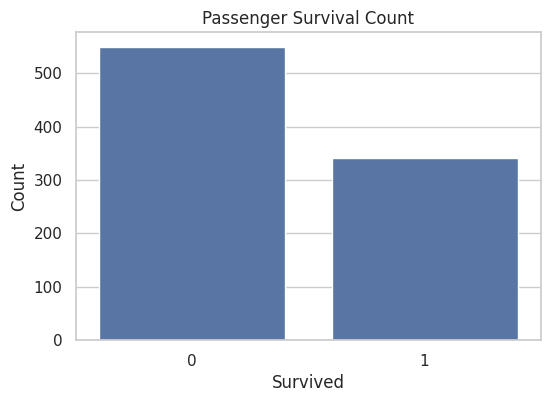

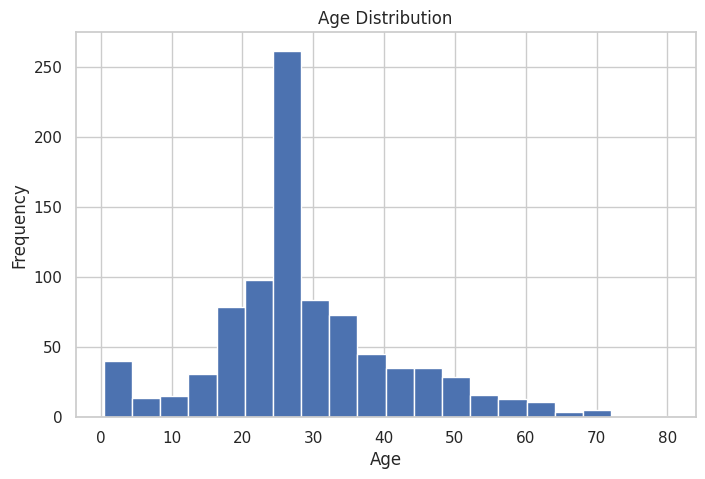

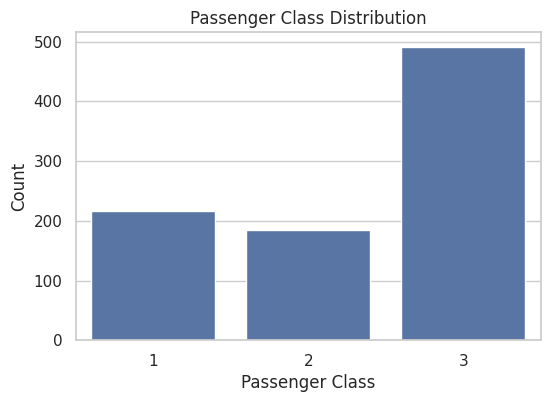

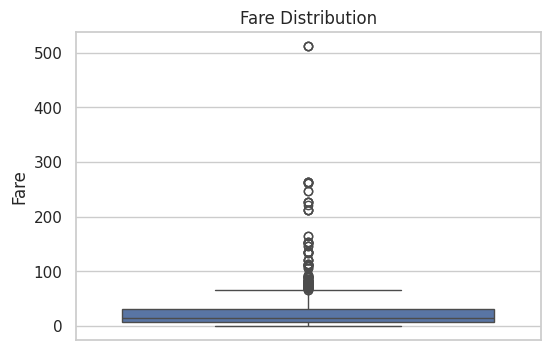

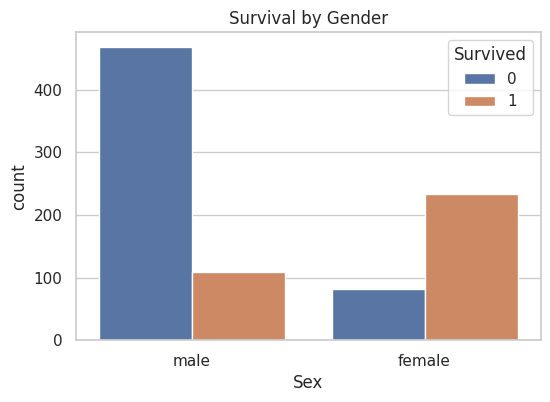

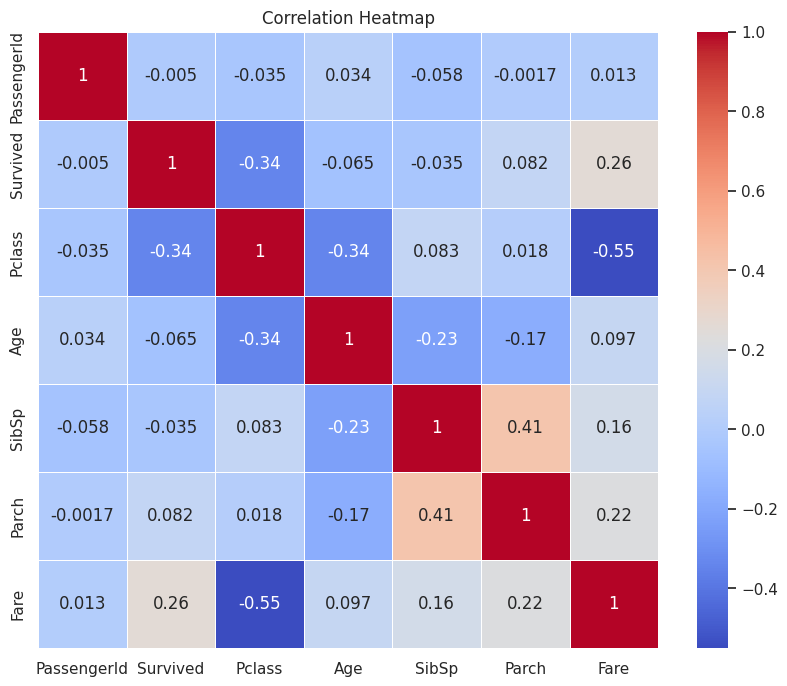


========== AVERAGE AGE ==========
29.36158249158249

========== AVERAGE FARE ==========
32.204207968574636

========== SURVIVAL COUNT ==========
Survived
0    549
1    342
Name: count, dtype: int64

========== PASSENGER CLASS COUNT ==========
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

========== GENDER COUNT ==========
Sex
male      577
female    314
Name: count, dtype: int64

Cleaned dataset saved successfully as 'cleaned_titanic.csv'


In [4]:

# ======================================================
# NSDC Virtual Data Science with Python Internship
# Week 1 Task
# Data Acquisition, Cleaning & Exploratory Data Analysis
# ======================================================

# -------------------------
# 1. Import Libraries
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# -------------------------
# 2. Load Dataset
# -------------------------
df = pd.read_csv("train.csv")

print("========== FIRST 5 ROWS ==========")
print(df.head())

# -------------------------
# 3. Dataset Information
# -------------------------
print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATASET INFO ==========")
df.info()

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

# -------------------------
# 4. Missing Values
# -------------------------
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# -------------------------
# 5. Duplicate Rows
# -------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After Removal:", df.duplicated().sum())

# -------------------------
# 6. Data Cleaning
# -------------------------

# Fill missing Age values using Median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values using Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because it has too many missing values
df = df.drop(columns=["Cabin"])

print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(df.isnull().sum())

# -------------------------
# 7. Data Types
# -------------------------
print("\n========== DATA TYPES ==========")
print(df.dtypes)

# -------------------------
# 8. Summary Statistics
# -------------------------
print("\n========== SUMMARY STATISTICS ==========")
print(df.describe())

# ======================================================
# Exploratory Data Analysis
# ======================================================

sns.set_style("whitegrid")

# -------------------------
# Visualization 1
# Survival Count
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived")
plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# -------------------------
# Visualization 2
# Age Distribution
# -------------------------
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# Visualization 3
# Passenger Class
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

# -------------------------
# Visualization 4
# Fare Boxplot
# -------------------------
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Fare"])
plt.title("Fare Distribution")
plt.show()

# -------------------------
# Visualization 5
# Survival by Gender
# -------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

# -------------------------
# Visualization 6
# Correlation Heatmap
# -------------------------
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# ======================================================
# Additional Analysis
# ======================================================

print("\n========== AVERAGE AGE ==========")
print(df["Age"].mean())

print("\n========== AVERAGE FARE ==========")
print(df["Fare"].mean())

print("\n========== SURVIVAL COUNT ==========")
print(df["Survived"].value_counts())

print("\n========== PASSENGER CLASS COUNT ==========")
print(df["Pclass"].value_counts())

print("\n========== GENDER COUNT ==========")
print(df["Sex"].value_counts())

# ======================================================
# Save Cleaned Dataset
# ======================================================

df.to_csv("cleaned_titanic.csv", index=False)

print("\nCleaned dataset saved successfully as 'cleaned_titanic.csv'")